# This notebook is used to plot curvefit for the subtlety data (april sess 1 and 2)

In [6]:
import sys,os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import ttest_rel,wilcoxon
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
import os

In [7]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [8]:
path_to_add = os.path.abspath('../')
path_to_add

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper_DropBox/version4_copyof_version3_March2025/scripts_data_for_beh_paper/code'

In [9]:
sys.path.append(path_to_add)
from func_curvefit import *
import seaborn as sns

In [10]:
# root_data_file = '../../data/playfight_data'
root_folder = '../../data/playfight_data/'

In [11]:
curvefit_ses1 = pd.read_csv(f'{root_folder}/curve_fit_aggressiveness_ses1_linear/all_params_1k_fight_linear.csv')#merged_apr_ses1.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:]# has bad subs

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
14,26014.0,0.000000e+00,0.303568,-40.518924,inf,0.000000,0.352286,0.352286,0.647714,0.0,0.0,False
55,26060.0,7.984686e-02,0.302446,-38.842548,-5.144827,0.041429,NaN,0.286857,0.754571,1.0,1.0,True
70,26079.0,3.750000e-01,0.276642,-18.983900,-0.388889,0.450000,0.675000,0.675000,-0.125000,0.0,0.0,False
150,26165.0,3.891542e-01,0.232675,-33.504478,-1.486093,0.164357,NaN,0.255750,0.908607,1.0,1.0,True
175,26195.0,-2.220446e-16,0.309204,-30.304180,-inf,0.000000,NaN,0.379444,0.620556,1.0,1.0,True
257,26285.0,2.157118e-02,0.348544,-42.059395,-0.302487,0.016595,NaN,0.494980,0.521615,1.0,1.0,True
308,26338.0,5.491162e-01,0.228676,-37.415560,-1.493350,0.171857,NaN,0.243357,0.928500,1.0,1.0,True


# clean data

In [12]:
# clean data
curvefit_ses1 = fix_obj_center(curvefit_ses1)
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # bad subs bc of obj_center removed. rest will be removed with neg amplitudes

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
55,26060.0,7.984686e-02,0.302446,-38.842548,NaN,0.041429,NaN,0.286857,0.754571,1.0,1.0,True
150,26165.0,3.891542e-01,0.232675,-33.504478,NaN,0.164357,NaN,0.255750,0.908607,1.0,1.0,True
173,26193.0,9.428737e-01,0.083005,-30.885994,NaN,0.962103,NaN,0.962203,0.999900,1.0,1.0,True
175,26195.0,-2.220446e-16,0.309204,-30.304180,NaN,0.000000,NaN,0.379444,0.620556,1.0,1.0,True
178,26198.0,2.821719e-01,0.280972,-39.169052,NaN,0.086143,NaN,0.594452,0.491690,1.0,1.0,True
227,26253.0,5.391453e-01,0.254507,-36.419557,NaN,0.180857,NaN,0.619571,0.561286,1.0,1.0,True
257,26285.0,2.157118e-02,0.348544,-42.059395,NaN,0.016595,NaN,0.494980,0.521615,1.0,1.0,True
308,26338.0,5.491162e-01,0.228676,-37.415560,NaN,0.171857,NaN,0.243357,0.928500,1.0,1.0,True


In [13]:
curvefit_ses1 = add_new_params(curvefit_ses1)
curvefit_ses1.loc[curvefit_ses1['range']<0,:] # has neg range rows

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
55,26060.0,0.079847,0.302446,-38.842548,NaN,0.041429,NaN,0.286857,0.754571,1.0,1.0,True,-0.041429,0.275446
150,26165.0,0.389154,0.232675,-33.504478,NaN,0.164357,NaN,0.255750,0.908607,1.0,1.0,True,-0.164357,0.219649
173,26193.0,0.942874,0.083005,-30.885994,NaN,0.962103,NaN,0.962203,0.999900,1.0,1.0,True,-0.962103,0.490394
178,26198.0,0.282172,0.280972,-39.169052,NaN,0.086143,NaN,0.594452,0.491690,1.0,1.0,True,-0.086143,0.547306
227,26253.0,0.539145,0.254507,-36.419557,NaN,0.180857,NaN,0.619571,0.561286,1.0,1.0,True,-0.180857,0.524679
257,26285.0,0.021571,0.348544,-42.059395,NaN,0.016595,NaN,0.494980,0.521615,1.0,1.0,True,-0.016595,0.486900
308,26338.0,0.549116,0.228676,-37.415560,NaN,0.171857,NaN,0.243357,0.928500,1.0,1.0,True,-0.171857,0.207668


In [14]:
curvefit_ses1

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
0,26000.0,0.940328,0.089873,-35.484797,0.709516,0.704565,0.000100,0.000100,0.295335,0.0,0.0,False,0.704565,0.000338
1,26001.0,0.823224,0.147384,-35.444795,0.594001,0.386857,0.270206,0.270206,0.342937,0.0,0.0,False,0.386857,0.440691
2,26002.0,0.799844,0.174349,-27.675491,0.550578,0.624214,0.156321,0.156321,0.219464,0.0,0.0,False,0.624214,0.415986
3,26003.0,0.915302,0.111619,-26.697277,0.499900,1.000000,0.000100,0.000100,0.000000,0.0,0.0,False,0.999900,1.000000
4,26004.0,0.972040,0.051894,-43.866039,0.526637,0.579214,0.194964,0.194964,0.225821,0.0,0.0,False,0.579214,0.463334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,26344.0,0.849478,0.155297,-23.720998,0.606647,0.824037,0.000100,0.000100,0.175863,0.0,0.0,False,0.824037,0.000568
315,26345.0,0.803122,0.179504,-20.200661,0.391841,1.000000,0.108159,0.108159,0.000000,0.0,0.0,False,0.891841,1.000000
316,26346.0,0.855388,0.122336,-30.751435,0.511248,0.609643,0.188321,0.188321,0.202036,0.0,0.0,False,0.609643,0.482434
317,26347.0,0.852070,0.125535,-43.857648,0.824250,0.235905,0.305556,0.305556,0.458540,0.0,0.0,False,0.235905,0.399892


In [15]:
curvefit_ses1.loc[curvefit_ses1['range']==0,:] # has neg range rows

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
14,26014.0,0.000000e+00,0.303568,-40.518924,1.0,0.0,0.352286,0.352286,0.647714,0.0,0.0,False,0.0,0.352286
175,26195.0,-2.220446e-16,0.309204,-30.304180,NaN,0.0,NaN,0.379444,0.620556,1.0,1.0,True,0.0,0.379444


In [16]:
curvefit_ses1 = curvefit_ses1.loc[curvefit_ses1['range']>0,:] # remove negative amplitudes
curvefit_ses1.loc[curvefit_ses1['range']<0,:] 

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [17]:
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:]# all bad subs removed

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [18]:
curvefit_ses1.rename(columns={'obj_center':'PSE'},inplace=True) # rename obj_center

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_29311/438379356.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curvefit_ses1.rename(columns={'obj_center':'PSE'},inplace=True) # rename obj_center


# plot histograms of the good data

In [23]:
# imp_cols = ['range','bias', 'PSE', 'slope', 'bias_xmin','bias_xmax'] #['slope','bias']
imp_cols = ['PSE','bias', 'range', 'slope', 'bias_xmin','bias_xmax'] #['slope','bias']

In [24]:
curvefit_ses1.loc[np.isinf(curvefit_ses1['bias']),:]

,subID,r_squared,nrmse,aic,PSE,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [35]:
# ticks_all = {'PSE':[0,0.3,0.6],'range':[0,0.5,1],'bias':[0,0.5,1]}
ticks_all = {'PSE':[0,0.3,0.6],'range':[0,0.5,1],'bias':[0,0.5,1]}

In [36]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [37]:
col

'PSE'

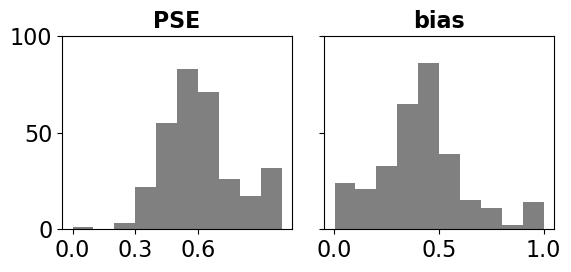

In [38]:
fig,axs=plt.subplots(figsize=(6,3),ncols=len(imp_cols[:2]),nrows=1,sharey=True)
for i,col in enumerate(imp_cols[:2]):
    ax = axs[i]
    ax.hist(curvefit_ses1[col], color = 'grey')
    ax.set_title(col,fontweight='bold')
    ax.set_xticks(ticks_all[col])
    ax.set_ylim(0,100)
    if i == 0:
        ax.set_yticks([0,50,100])
plt.tight_layout()
plt.savefig('../../results/playfight/params_histogram_pf.png',dpi=300)

In [28]:
s=18 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [31]:
supp_cols = ['PSE','slope','lb','ub']#,'aic']
# ticks_all = {'PSE':[0,0.5,1],'slope':[0,0.5,1],'bias_xmin':[0,0.35,0.7],'bias_xmax':[0,0.45,0.9]}
ticks_all = {'range':[0,0.5,1],'slope':[0,0.5,1],'bias_xmin':[0,0.35,0.7],'bias_xmax':[0,0.45,0.9]}

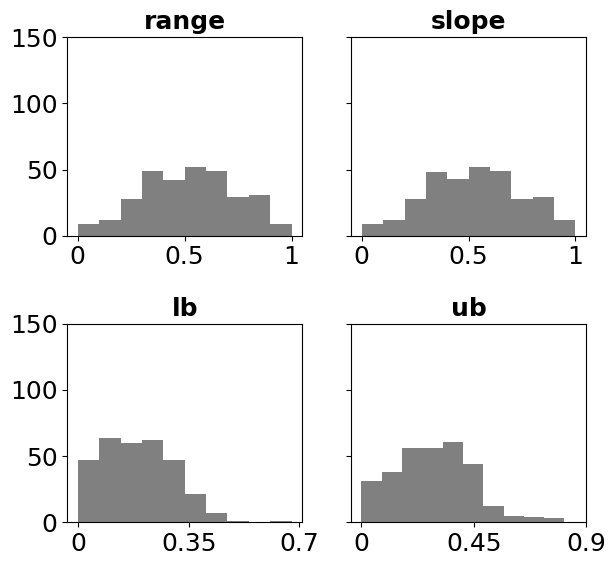

In [32]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3.25*int(len(imp_cols[2:])/2),3*int(len(imp_cols[2:])/2)),sharey=True)
for i,col in enumerate(imp_cols[2:]):
    r = int(np.floor(i/2))
    c = i%2
    ax = axs[r,c]
    # ax = axs[i]
    ax.hist(curvefit_ses1[col], color = 'grey')
    if col == 'bias_xmin':
        title = 'lb'
    elif col == 'bias_xmax':
        title = 'ub'
    else:
        title = col
    ax.set_title(title,fontweight='bold',fontsize=18)
    ax.set_ylim(0,150)
    ax.set_xticks(ticks_all[col])
    limits = [ax.get_xlim()[0],ax.get_xlim()[1]]
    ax.set_xlim(limits)
    ticks = ticks_all[col]
    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))
    ax.set_xticks(ticks,ticklabels)
plt.tight_layout()
plt.savefig('../../results/playfight/params_histogram_pf_extra.png',dpi=300)